<a href="https://colab.research.google.com/github/artwellql/First_repo/blob/main/Hw2.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Новий розділ

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io

In [67]:

url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
html_data = io.StringIO(response.text)

tables = pd.read_html(html_data, match="Коефіцієнт народжуваності")
df = tables[0]


In [69]:
print(df.head())

             Регіон   1950   1960   1970  1990  2000  2012 2014 2019
0              Крим  230.0  206.0  160.0   130    73   126    —    —
1         Вінницька  224.0  192.0  142.0   124    84   112  109   76
2         Волинська  247.0  250.0  179.0   153   112   148  141  101
3  Дніпропетровська  204.0  204.0  151.0   123    71   112  111   71
4          Донецька  271.0  214.0  140.0   109    61    98   82    —


In [70]:
print(df.shape)

(28, 9)


In [71]:
df = df.replace("—", np.nan)

In [72]:
print(df.dtypes)


Регіон     object
1950      float64
1960      float64
1970      float64
1990        int64
2000        int64
2012        int64
2014       object
2019       object
dtype: object


In [73]:
columns = df.columns[1:]
df[columns] = df[columns].apply(pd.to_numeric, errors='coerce')

In [74]:
print(df.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990        int64
2000        int64
2012        int64
2014      float64
2019      float64
dtype: object


In [75]:
missing_fraction = df.isnull().sum() / len(df)
print(missing_fraction)

Регіон    0.000000
1950      0.071429
1960      0.035714
1970      0.035714
1990      0.000000
2000      0.000000
2012      0.000000
2014      0.071429
2019      0.142857
dtype: float64


In [76]:
df = df[:-1]

In [77]:
df = df.fillna(df.mean(numeric_only=True))

In [78]:
mean_2019 = df['2019'].mean()
top_regions = df[df['2019'] > mean_2019]['Регіон'].tolist()
print(top_regions)

['Волинська', 'Закарпатська', 'Івано-Франківська', 'Львівська', 'Одеська', 'Рівненська', 'Херсонська', 'Чернівецька', 'Київ']


In [79]:
max_index_2014 = df['2014'].idxmax()
best_region_2014 = df.loc[max_index_2014, 'Регіон']
print(best_region_2014)

Рівненська


<Axes: xlabel='Регіон'>

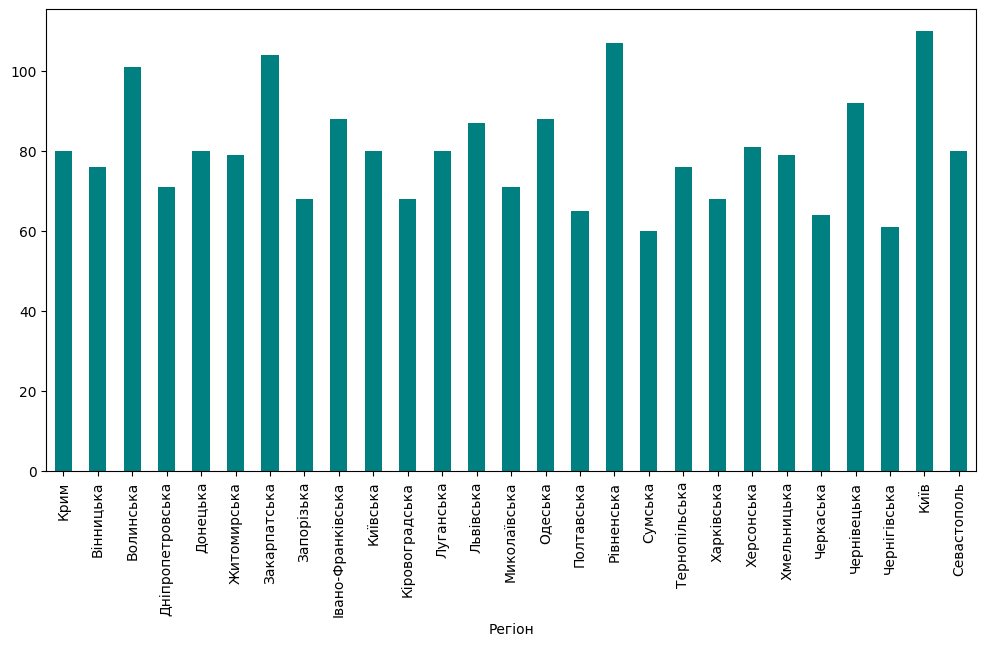

In [82]:
df_plot = df.set_index('Регіон')
df_plot['2019'].plot(kind='bar', figsize=(12, 6), color='teal')